# Synthea COVID-19 Module Analysis
This notebook provides and analysis of data generated by Synthea's COVID-19 module. Analysis is run on the CSV output from Synthea.

Exploring the synthetic data with duckdb

COVID-19
COVID-19 10K, CSV | [mirror]: 54 MB
Ten thousand synthetic patients records with COVID-19 in the CSV format.
COVID-19 100K, CSV: 512 MB
One hundred thousand synthetic patients records with COVID-19 in the CSV format.
Please cite the SyntheaTM COVID-19 data as:

Walonoski J, Klaus S, Granger E, Hall D, Gregorowicz A, Neyarapally G, Watson A, Eastman J. Synthea™ Novel coronavirus (COVID-19) model and synthetic data set. Intelligence-Based Medicine. 2020 Nov;1:100007. https://doi.org/10.1016/j.ibmed.2020.100007

In [1]:
# download 10k synthetic data
# !wget https://mitre.box.com/shared/static/9iglv8kbs1pfi7z8phjl9sbpjk08spze.zip
# !unzip 9iglv8kbs1pfi7z8phjl9sbpjk08spze.zip
# !mv -v 10k_synthea_covid19_csv/* .

# download 100k synthetic data
!wget https://mitre.box.com/shared/static/wk3560f962ozlg7sd2oj1zxk73ayqvm0.zip
!unzip wk3560f962ozlg7sd2oj1zxk73ayqvm0.zip
!mv -v 100k_synthea_covid19_csv/* .

--2025-12-26 05:22:56--  https://mitre.box.com/shared/static/wk3560f962ozlg7sd2oj1zxk73ayqvm0.zip
Resolving mitre.box.com (mitre.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to mitre.box.com (mitre.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/wk3560f962ozlg7sd2oj1zxk73ayqvm0.zip [following]
--2025-12-26 05:22:57--  https://mitre.box.com/public/static/wk3560f962ozlg7sd2oj1zxk73ayqvm0.zip
Reusing existing connection to mitre.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://mitre.app.box.com/public/static/wk3560f962ozlg7sd2oj1zxk73ayqvm0.zip [following]
--2025-12-26 05:22:57--  https://mitre.app.box.com/public/static/wk3560f962ozlg7sd2oj1zxk73ayqvm0.zip
Resolving mitre.app.box.com (mitre.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to mitre.app.box.com (mitre.app.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiti

In [65]:
import glob
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import datetime
from pathlib import Path
from typing import Tuple
import numpy as np

In [3]:
def load_table(connection: duckdb.DuckDBPyConnection, table: str, path: str) -> None:
    con.execute(
        f'CREATE OR REPLACE TABLE "{table}" AS SELECT * FROM read_csv_auto({path}, HEADER=TRUE);'
    )

In [4]:
# glob * csv into a list named csv_files

csv_files = glob.glob('*.csv')
csv_files

['medications.csv',
 'providers.csv',
 'encounters.csv',
 'devices.csv',
 'careplans.csv',
 'immunizations.csv',
 'payers.csv',
 'patients.csv',
 'conditions.csv',
 'organizations.csv',
 'observations.csv',
 'procedures.csv',
 'supplies.csv',
 'payer_transitions.csv',
 'imaging_studies.csv',
 'allergies.csv']

In [5]:
# Connect to a local DuckDB database
con = duckdb.connect('10k_synthea_covid19.db')

In [ ]:
# # Ingest Single csv
# tablename = 'immunizations'
# file = 'immunizations.csv'
# load_table(con, tablename, Path(file))

In [14]:
! du -hsc *.csv

5.8M	allergies.csv
73M	careplans.csv
135M	conditions.csv
5.0M	devices.csv
944M	encounters.csv
11M	imaging_studies.csv
22M	immunizations.csv
954M	medications.csv
2.3G	observations.csv
1.4M	organizations.csv
34M	patients.csv
4.0K	payers.csv
36M	payer_transitions.csv
155M	procedures.csv
11M	providers.csv
191M	supplies.csv
4.8G	total


On a system with 12.7 Gb system ram takes about 1 min to load 4.8 Gb of csv

In [6]:
for file in csv_files:
    tablename = file.split('.')[0]
    print(f"Loading {tablename}")
    load_table(con,tablename, file)

Loading medications


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loading providers
Loading encounters


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loading devices
Loading careplans
Loading immunizations
Loading payers
Loading patients
Loading conditions


...

Loading organizations
Loading observations


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loading procedures
Loading supplies


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loading payer_transitions
Loading imaging_studies
Loading allergies


In [9]:
# Grab the IDs of patients that have been diagnosed with COVID-19
result = con.execute("""
SELECT DISTINCT PATIENT
FROM conditions
WHERE CODE = '840539006'
""").fetchall()

covid_patient_ids_duckdb = [row[0] for row in result]

print(covid_patient_ids_duckdb)

['f31a441e-21e4-42b6-962c-30811ea011fa', '22dab53b-d9e5-4d00-a755-9b1d174aebaf', '9617f33d-d1d3-4c7f-b876-324b0e47e6c6', '22ca32a2-a597-4edd-b651-79dc560844b8', '8e52047c-8009-4e94-990a-708d1ea34243', '2f649887-4f16-4bc1-9219-0ef57793d7db', '78c412de-be1d-4af8-b236-94b4b01574d4', 'b5b9e27b-5998-4ff4-b451-8c0e8a4ce775', '0b2da4d5-6bb1-4dba-b5e9-e103d86dc380', '2c90abc6-c7b1-4243-baa2-bf6e45ec85b4', '5ea73737-5885-4ee5-8197-96a7a9eedaab', 'a762936c-c7bd-4dcc-9238-909c5ce082b6', '0f4099f4-b964-4c98-9eb2-801d15d5aac8', 'aef7392d-8f0d-4eda-a444-95698ffc4117', 'f19db4a4-0285-4a90-867e-36f33b626c2f', '09cd00cc-0163-4fec-9ae2-ddf96b81e767', 'ef866163-9887-4bd5-b4d6-6638ca02e694', '6d361556-f03f-45b1-9696-429872a91485', 'e745c104-1359-4568-b7fd-9732a294a1f9', '2e4a99e5-17b6-41ed-8674-dc54fa06cf39', 'c6d00ebd-8a0e-440d-93b5-66403a4de082', '82ff6b8a-7efe-40c3-9e02-d4aa1da3c005', '9c47cc84-d9a4-489a-a816-eb2bd3062eb6', 'ac8ecaaf-3d66-403c-833c-0d015f2b8391', '103d6a2c-0ed4-4f48-a0ca-21dd0209a35c',

In [10]:
print(f"Number of patients with COVID-19: {len(covid_patient_ids_duckdb)}")

Number of patients with COVID-19: 88166


# Patients with negative test results
This grabs every patient with a negative SARS-CoV-2 test. This will include patients who tested negative up front as well as patients that tested negative after leaving the hospital

In [15]:
# DuckDB SQL to find unique patient IDs with a negative COVID-19 observation
result_negative = con.execute("""
SELECT DISTINCT PATIENT
FROM observations
WHERE CODE = '94531-1' AND VALUE = 'Not detected (qualifier value)'
""").fetchall()


Grabs IDs for all patients that died in the simulation. This will be more than just COVID-19 deaths.

In [16]:
# DuckDB SQL to find deceased patients
result_deceased = con.execute("""
SELECT Id
FROM patients
WHERE DEATHDATE IS NOT NULL
""").fetchall()

deceased_patient_ids_duckdb = [row[0] for row in result_deceased]

print(deceased_patient_ids_duckdb)

['a89e2d41-db41-4bf2-8e7d-f315743219dd', '87b26350-3798-4289-a2ee-f6d88145537f', '87537cb1-92e1-4a11-8dd7-e62631a3d8a8', 'c65a8f2f-82c1-44b5-8afb-7310da58e3fe', '8742348d-72b0-40b3-a970-08e50b30e256', '51d777f5-60fd-42fd-9722-63407a3db63f', '8dbd714f-fae1-4a21-bdd4-960d3b08f52d', 'cabf1029-f139-49dc-9aef-bcbb491003eb', '59902107-60f4-4654-8361-43cb5dcee0fb', '9f88fc9f-27ea-4e83-bfdf-cff0ffe0f6e1', '7864b229-df36-48ba-99fa-dfacb4622a8c', 'e54bf08f-f359-450a-8702-a87397642725', 'e1078d76-d0b6-44a5-bf31-5e608838e44f', '921450ae-433f-41ff-a76a-ea114be1d69c', 'a06df52a-f0a5-459a-9875-972cb2d558b5', '98ccb593-1ee7-4f22-b3a8-2ac11a34d977', '1cef2bca-59bf-4e9a-93c8-198ce940c49b', '78bf19ff-9f45-4aa5-a875-89d6bc713c7a', 'eed3cbc0-843f-4bfb-90b4-aa2bf184c3a2', '650ead05-6776-4e57-87dc-44585aea4413', '03533487-733a-49a7-83ca-306c3bd8a792', '05c9b8c5-43ad-461d-a571-b5b7c02d0df5', 'd58c577c-b773-4d0d-9c65-ba07ef19f821', '297ba3b2-2f99-4b89-af26-11256d25f4c9', 'abf66208-ae61-43e8-9e76-a64a2ed0b94e',

In [17]:
print(f"Number of deceased patients: {len(deceased_patient_ids_duckdb)}")

Number of deceased patients: 24150


In [18]:
#  DuckDB SQL to find patients who completed isolation
result_completed_isolation = con.execute("""
SELECT PATIENT
FROM careplans
WHERE CODE = '736376001'
  AND STOP IS NOT NULL
  AND REASONCODE = '840539006'
""").fetchall()

completed_isolation_patient_ids_duckdb = [row[0] for row in result_completed_isolation]

print(completed_isolation_patient_ids_duckdb)

['1ff7f10f-a204-4bb1-aa72-dd763fa99482', '9bcf6ed5-d808-44af-98a0-7d78a29ede72', '5163c501-353c-4a82-b863-a3f1df2d6cf1', 'cc3c806f-4a09-4a89-a990-4286450956be', '4dc153b6-bd07-49f3-bb4c-bad875b388a3', '9d873139-72ec-4711-9ebd-f278e100a499', '15eab0f6-a733-493d-9b4b-8dba8faa4565', '09303bc9-3bcc-49fe-b57b-005471833c43', 'eabb35fd-651b-45e3-bd42-cef1cb5133fc', 'da454f92-9e90-43f8-9514-550fbaa6de3d', '29581d13-2687-402f-9c4c-06141a319e61', 'b03dce84-61de-4393-8db5-62795aa48939', 'e52bd28f-82df-41da-97f1-556ecb8514d2', 'af51fb48-22f9-4ffb-a843-8b840afc6976', 'beb7c8b8-f5c0-4656-a5b0-fef87dc8a006', 'c4327c43-7028-42e7-81f4-b477dd8e4b8e', '8920d5e2-2e44-4fea-8644-55ae291f3dc7', '7efa9ef2-ec13-47cd-a8eb-5a259114bce9', 'c5e617da-998c-422c-a2f3-3b471b8a4ebe', 'ba734af2-1aad-49c2-8867-940f9cd41b83', 'a7690822-57eb-4e82-97c5-1ebe6440f272', 'b1f4c745-d24e-4032-a051-5fc799542220', 'd6f140be-c4a3-421e-aab3-6ae75970de60', '29bc0101-dc59-4038-adf6-699e1d94e0e6', '43ae7ae0-55cc-4814-82f6-4cd363cccdcb',

In [20]:
print(f"Number of patients who completed isolation: {len(completed_isolation_patient_ids_duckdb)}")

Number of patients who completed isolation: 70398


In [26]:
survivor_ids = np.union1d(completed_isolation_patient_ids_duckdb, result_negative)

In [28]:
len(survivor_ids)

87485

In [21]:
# Grab IDs for patients with admission due to COVID-19
result_inpatient = con.execute("""
SELECT PATIENT
FROM encounters
WHERE REASONCODE = '840539006' AND CODE = '1505002'
""").fetchall()

inpatient_ids_duckdb = [row[0] for row in result_inpatient]

print(inpatient_ids_duckdb)

['bd1c4ffc-7f1d-4590-adbb-1d6533fb623e', '3c3b89b1-cb41-4f94-9193-2f3da4fe38e5', '7e2c6949-dce9-44be-b6ef-50aca95840d7', '0ab3b40f-3afd-42b8-9755-5834aa42eb67', '346b2b95-b8c5-4fe1-acf3-94de7e6e965b', '84e925e1-599a-4b29-83f2-ded2e1d97334', '86644fef-f749-4951-90d5-ce38ff2e547a', 'a89e2d41-db41-4bf2-8e7d-f315743219dd', 'dda53672-1ea1-4255-b177-0fc3a6f33929', 'a2a8e809-cc34-4f8e-93b8-74e4a87f35ef', '24b98926-9b5a-4537-b35c-2c4c3f790ebd', '2252343c-ebeb-46c9-8dc4-5ff972b7cf16', 'c81ff919-4e34-44c3-87d4-88124cd5a541', '87537cb1-92e1-4a11-8dd7-e62631a3d8a8', '585c0ce0-2772-4bdf-af51-f8b685a507cd', '3db03e4c-e220-4e41-948c-a9ff2dc274f6', '51d777f5-60fd-42fd-9722-63407a3db63f', '30ce94e8-8c50-4588-97f6-b8aa1df0e9d2', 'eb22bc30-57c9-481a-a660-36816ea94d74', '0718d553-98ef-4424-8070-7f3ad81c3ce2', '13509f96-2ed4-4e8b-bc5d-991f785d6ea2', 'e43fe5fb-3841-4690-b2a6-cca56edd7916', '1177083e-08f4-4592-8dfa-7ca1aff53ebd', 'ca17602b-8df5-4600-aa0f-172e77a4a23a', 'fb7d26ea-aa15-495e-982a-cf0c3aa53ec1',

In [22]:
print(f"Number of patients who were inpatients: {len(inpatient_ids_duckdb)}")

Number of patients who were inpatients: 18177


In [29]:
# The number of inpatient survivors
np.intersect1d(inpatient_ids_duckdb, survivor_ids).shape

(14654,)

In [30]:
# The number of inpatient non-survivors
np.intersect1d(inpatient_ids_duckdb, deceased_patient_ids_duckdb).shape

(3548,)

In [34]:
# ! wget https://raw.githubusercontent.com/kevin3/module-validation/refs/heads/master/notebooks/analysis.py
import analysis

In [37]:
!ls -lh conditions*
conditions = pd.read_csv("./conditions.csv") #refactor

# conditions = con.execute("""
# SELECT *
# FROM conditions
# """).fetchall()

-rw-r--r-- 1 root root 135M May 26  2020 conditions.csv


In [39]:
conditions

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2019-02-15,2019-08-01,1ff7f10f-a204-4bb1-aa72-dd763fa99482,d317dacb-d801-4136-be7d-440094f7ae83,65363002,Otitis media
1,2019-10-30,2020-01-30,1ff7f10f-a204-4bb1-aa72-dd763fa99482,759cfd9c-b40b-45df-a5b2-fca418027a6a,65363002,Otitis media
2,2020-03-01,2020-03-30,1ff7f10f-a204-4bb1-aa72-dd763fa99482,60584c6a-e26b-4176-a660-86ad84c7ceca,386661006,Fever (finding)
3,2020-03-01,2020-03-01,1ff7f10f-a204-4bb1-aa72-dd763fa99482,60584c6a-e26b-4176-a660-86ad84c7ceca,840544004,Suspected COVID-19
4,2020-03-01,2020-03-30,1ff7f10f-a204-4bb1-aa72-dd763fa99482,60584c6a-e26b-4176-a660-86ad84c7ceca,840539006,COVID-19
...,...,...,...,...,...,...
1143895,2019-06-07,2019-06-14,f8d85cff-037c-4313-9448-14ac57d586a8,b8b0fbbe-0eb6-4ba5-8b88-4018ae86a934,444814009,Viral sinusitis (disorder)
1143896,2020-03-09,2020-04-05,f8d85cff-037c-4313-9448-14ac57d586a8,f2cadc10-2d46-42a8-80db-2893c700b50b,248595008,Sputum finding (finding)
1143897,2020-03-09,2020-04-05,f8d85cff-037c-4313-9448-14ac57d586a8,f2cadc10-2d46-42a8-80db-2893c700b50b,386661006,Fever (finding)
1143898,2020-03-09,2020-03-09,f8d85cff-037c-4313-9448-14ac57d586a8,f2cadc10-2d46-42a8-80db-2893c700b50b,840544004,Suspected COVID-19


In [38]:
analysis.outcome_table(inpatient_ids_duckdb, survivor_ids, deceased_patient_ids_duckdb, conditions)

,outcome,total,percent of inpatient,survivors,percent survivors,non survivors,percent non survivors
0,Sepsis,6945,0.381551,3419,0.233315,3526,0.993799
1,Respiratory Failure,8710,0.478519,5237,0.357377,3473,0.978861
2,ARDS,2401,0.131909,85,0.005800,2316,0.652762
3,Heart Failure,1434,0.078783,124,0.008462,1310,0.369222
4,Septic Shock,1746,0.095924,0,0.000000,1746,0.492108
5,Coagulopathy,1389,0.076310,91,0.006210,1298,0.365840
6,Acute Cardiac Injury,1288,0.070761,20,0.001365,1268,0.357384
7,Acute Kidney Injury,1252,0.068784,8,0.000546,1244,0.350620


In [47]:
lab_obs_result = con.execute("""
SELECT *
FROM observations
WHERE CODE IN ('48065-7', '26881-3', '2276-4', '89579-7', '2532-0', '731-0', '14804-9')
""").fetchall()

# Convert the result to a pandas DataFrame with the correct number of columns
lab_obs = pd.DataFrame(lab_obs_result, columns=["DATE", "PATIENT", "ENCOUNTER", "CODE", "DESCRIPTION", "VALUE", "UNITS", "TYPE"]) # Added 'TYPE' column

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [48]:
lab_obs

,DATE,PATIENT,ENCOUNTER,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2020-02-19,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,b7455838-3607-47f4-aaa5-fd89abea7d29,731-0,Lymphocytes [#/volume] in Blood by Automated c...,1.1,10*3/uL,numeric
1,2020-02-19,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,b7455838-3607-47f4-aaa5-fd89abea7d29,48065-7,Fibrin D-dimer FEU [Mass/volume] in Platelet p...,0.4,ug/mL,numeric
2,2020-02-19,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,b7455838-3607-47f4-aaa5-fd89abea7d29,2276-4,Ferritin [Mass/volume] in Serum or Plasma,332.4,ug/L,numeric
3,2020-02-19,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,b7455838-3607-47f4-aaa5-fd89abea7d29,89579-7,Troponin I.cardiac [Mass/volume] in Serum or P...,2.3,pg/mL,numeric
4,2020-02-19,bd1c4ffc-7f1d-4590-adbb-1d6533fb623e,b7455838-3607-47f4-aaa5-fd89abea7d29,14804-9,Lactate dehydrogenase [Enzymatic activity/volu...,223.9,U/L,numeric
...,...,...,...,...,...,...,...,...
716795,2020-03-18,503d768f-481c-46e2-bcdb-a6116686351a,4820e50c-5504-4cd5-b55b-5d4d78b18628,731-0,Lymphocytes [#/volume] in Blood by Automated c...,0.5,10*3/uL,numeric
716796,2020-03-18,503d768f-481c-46e2-bcdb-a6116686351a,4820e50c-5504-4cd5-b55b-5d4d78b18628,48065-7,Fibrin D-dimer FEU [Mass/volume] in Platelet p...,15.4,ug/mL,numeric
716797,2020-03-18,503d768f-481c-46e2-bcdb-a6116686351a,4820e50c-5504-4cd5-b55b-5d4d78b18628,2276-4,Ferritin [Mass/volume] in Serum or Plasma,1876.3,ug/L,numeric
716798,2020-03-18,503d768f-481c-46e2-bcdb-a6116686351a,4820e50c-5504-4cd5-b55b-5d4d78b18628,89579-7,Troponin I.cardiac [Mass/volume] in Serum or P...,51.7,pg/mL,numeric


In [44]:
lab_obs_result

[(datetime.date(2020, 2, 19),
  'bd1c4ffc-7f1d-4590-adbb-1d6533fb623e',
  'b7455838-3607-47f4-aaa5-fd89abea7d29',
  '731-0',
  'Lymphocytes [#/volume] in Blood by Automated count',
  '1.1',
  '10*3/uL',
  'numeric'),
 (datetime.date(2020, 2, 19),
  'bd1c4ffc-7f1d-4590-adbb-1d6533fb623e',
  'b7455838-3607-47f4-aaa5-fd89abea7d29',
  '48065-7',
  'Fibrin D-dimer FEU [Mass/volume] in Platelet poor plasma',
  '0.4',
  'ug/mL',
  'numeric'),
 (datetime.date(2020, 2, 19),
  'bd1c4ffc-7f1d-4590-adbb-1d6533fb623e',
  'b7455838-3607-47f4-aaa5-fd89abea7d29',
  '2276-4',
  'Ferritin [Mass/volume] in Serum or Plasma',
  '332.4',
  'ug/L',
  'numeric'),
 (datetime.date(2020, 2, 19),
  'bd1c4ffc-7f1d-4590-adbb-1d6533fb623e',
  'b7455838-3607-47f4-aaa5-fd89abea7d29',
  '89579-7',
  'Troponin I.cardiac [Mass/volume] in Serum or Plasma by High sensitivity method',
  '2.3',
  'pg/mL',
  'numeric'),
 (datetime.date(2020, 2, 19),
  'bd1c4ffc-7f1d-4590-adbb-1d6533fb623e',
  'b7455838-3607-47f4-aaa5-fd89abea

In [49]:
# Select COVID-19 conditions out of all conditions in the simulation

# covid_conditions = conditions[conditions.CODE == 840539006]

covid_conditions = con.execute("""
SELECT *
FROM conditions
WHERE CODE = '840539006'
""").fetchall

In [ ]:
# Merge the COVID-19 conditions with the patients

# covid_patients = covid_conditions.merge(patients, how='left', left_on='PATIENT', right_on='Id')



In [50]:
# Execute a DuckDB query to left join covid_conditions with the patients table
covid_patients  = con.execute("""
SELECT cc.*, p.BIRTHDATE, p.GENDER, p.RACE, p.ETHNICITY, p.MARITAL, p.ADDRESS, p.CITY, p.STATE, p.ZIP, p.LAT, p.LON, p.HEALTHCARE_EXPENSES, p.HEALTHCARE_COVERAGE
FROM conditions AS cc
LEFT JOIN patients AS p ON cc.PATIENT = p.Id
WHERE cc.CODE = '840539006'
""").fetchall()

# Convert the result to a pandas DataFrame for easier manipulation and display
covid_patients  = pd.DataFrame(covid_patients , columns=["START", "STOP", "PATIENT", "ENCOUNTER", "CODE", "DESCRIPTION", "BIRTHDATE", "GENDER", "RACE", "ETHNICITY", "MARITAL", "ADDRESS", "CITY", "STATE", "ZIP", "LAT", "LON", "HEALTHCARE_EXPENSES", "HEALTHCARE_COVERAGE"])

# Display the first few rows of the joined DataFrame
display(covid_patients.head())

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BIRTHDATE,GENDER,RACE,ETHNICITY,MARITAL,ADDRESS,CITY,STATE,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,2020-03-06,2020-03-15,45335e7f-a067-463d-a8f1-65e98f8c4f60,3e0e1626-62be-49f9-b575-30096af96910,840539006,COVID-19,1947-07-28,M,asian,nonhispanic,M,357 Dooley Tunnel Apt 94,Peabody,Massachusetts,None,42.549896,-70.968206,1598374.01,12475.64
1,2020-03-02,2020-03-28,2aced1c3-1dbb-4131-91a7-e0042ad8488a,0eea6a57-b57b-403d-9a01-d2dc45b4d4cd,840539006,COVID-19,2018-10-27,M,white,nonhispanic,None,635 Daugherty Tunnel,Needham,Massachusetts,02494,42.270908,-71.225463,38065.00,1097.44
2,2020-03-02,2020-03-28,fa317abf-8b87-4538-a1fb-f0ccc5d7ca3d,f550a966-6406-4389-ac20-1a75b873f640,840539006,COVID-19,2011-08-13,M,white,nonhispanic,None,804 Brekke Union,Rockland,Massachusetts,None,42.138546,-70.894676,212279.31,2452.36
3,2020-03-05,None,c8323782-5ca3-47df-9b8c-722ff6870a23,1af79d1d-67a1-4db6-bf39-287169706d69,840539006,COVID-19,1933-05-29,M,white,nonhispanic,M,951 Hessel Park Apt 6,Melrose,Massachusetts,None,42.425938,-71.066927,1804719.84,14099.04
4,2020-03-10,2020-04-15,509c4b36-34da-4178-a2d8-c56ecec5bcb2,d4196287-65e5-48fe-90c3-1e94e1b37729,840539006,COVID-19,1941-03-25,F,white,nonhispanic,M,237 Gulgowski Esplanade Apt 89,Lowell,Massachusetts,01851,42.620036,-71.339545,1451740.33,21995.76


In [51]:
# Add an attribute to the DataFrame indicating whether this is a survivor or not.

covid_patients['survivor'] = covid_patients.PATIENT.isin(survivor_ids)

In [52]:
# Reduce the columns on the DataFrame to ones needed

covid_patients = covid_patients[['START', 'PATIENT', 'survivor', 'CODE']]
covid_patients

,START,PATIENT,survivor,CODE
0,2020-03-06,45335e7f-a067-463d-a8f1-65e98f8c4f60,True,840539006
1,2020-03-02,2aced1c3-1dbb-4131-91a7-e0042ad8488a,True,840539006
2,2020-03-02,fa317abf-8b87-4538-a1fb-f0ccc5d7ca3d,True,840539006
3,2020-03-05,c8323782-5ca3-47df-9b8c-722ff6870a23,False,840539006
4,2020-03-10,509c4b36-34da-4178-a2d8-c56ecec5bcb2,True,840539006
...,...,...,...,...
88161,2020-03-09,6a256a6f-757d-4c8b-8274-0f200da062e7,True,840539006
88162,2020-03-14,b5b8799d-3123-4689-bb3a-301637295871,True,840539006
88163,2020-02-27,b55db891-1263-4410-9ad2-e84d8d0f0b39,False,840539006
88164,2020-03-10,a7c4f970-957c-418b-9748-5510faef32c7,True,840539006


In [54]:
# Calculate attributes needed to support the plot. Also coerce all lab values into a numeric data type.

covid_patients_obs = covid_patients.merge(lab_obs, on='PATIENT')
covid_patients_obs['START'] = pd.to_datetime(covid_patients_obs.START, utc=True)
covid_patients_obs['DATE'] = pd.to_datetime(covid_patients_obs.DATE)
# covid_patients_obs['lab_days'] = covid_patients_obs.DATE - covid_patients_obs.START
# covid_patients_obs['days'] = np.around(covid_patients_obs.lab_days / np.timedelta64(1, 'D'))
# covid_patients_obs['VALUE'] = pd.to_numeric(covid_patients_obs['VALUE'], errors='coerce')

In [59]:
covid_patients_obs.START

,START
0,2020-03-06 00:00:00+00:00
1,2020-03-06 00:00:00+00:00
2,2020-03-06 00:00:00+00:00
3,2020-03-06 00:00:00+00:00
4,2020-03-06 00:00:00+00:00
...,...
716759,2020-02-27 00:00:00+00:00
716760,2020-02-27 00:00:00+00:00
716761,2020-02-27 00:00:00+00:00
716762,2020-02-27 00:00:00+00:00


In [60]:
covid_patients_obs['START'] = covid_patients_obs['START'].dt.tz_localize(None)

In [58]:
covid_patients_obs.DATE

,DATE
0,2020-03-14
1,2020-03-14
2,2020-03-14
3,2020-03-14
4,2020-03-14
...,...
716759,2020-03-06
716760,2020-03-06
716761,2020-03-06
716762,2020-03-06


In [56]:
covid_patients_obs['DATE'] = pd.to_datetime(covid_patients_obs.DATE)

In [61]:
#after conver to timezone-naive format for above
covid_patients_obs['lab_days'] = covid_patients_obs.DATE - covid_patients_obs.START

In [62]:
covid_patients_obs['days'] = np.around(covid_patients_obs.lab_days / np.timedelta64(1, 'D'))
covid_patients_obs['VALUE'] = pd.to_numeric(covid_patients_obs['VALUE'], errors='coerce')

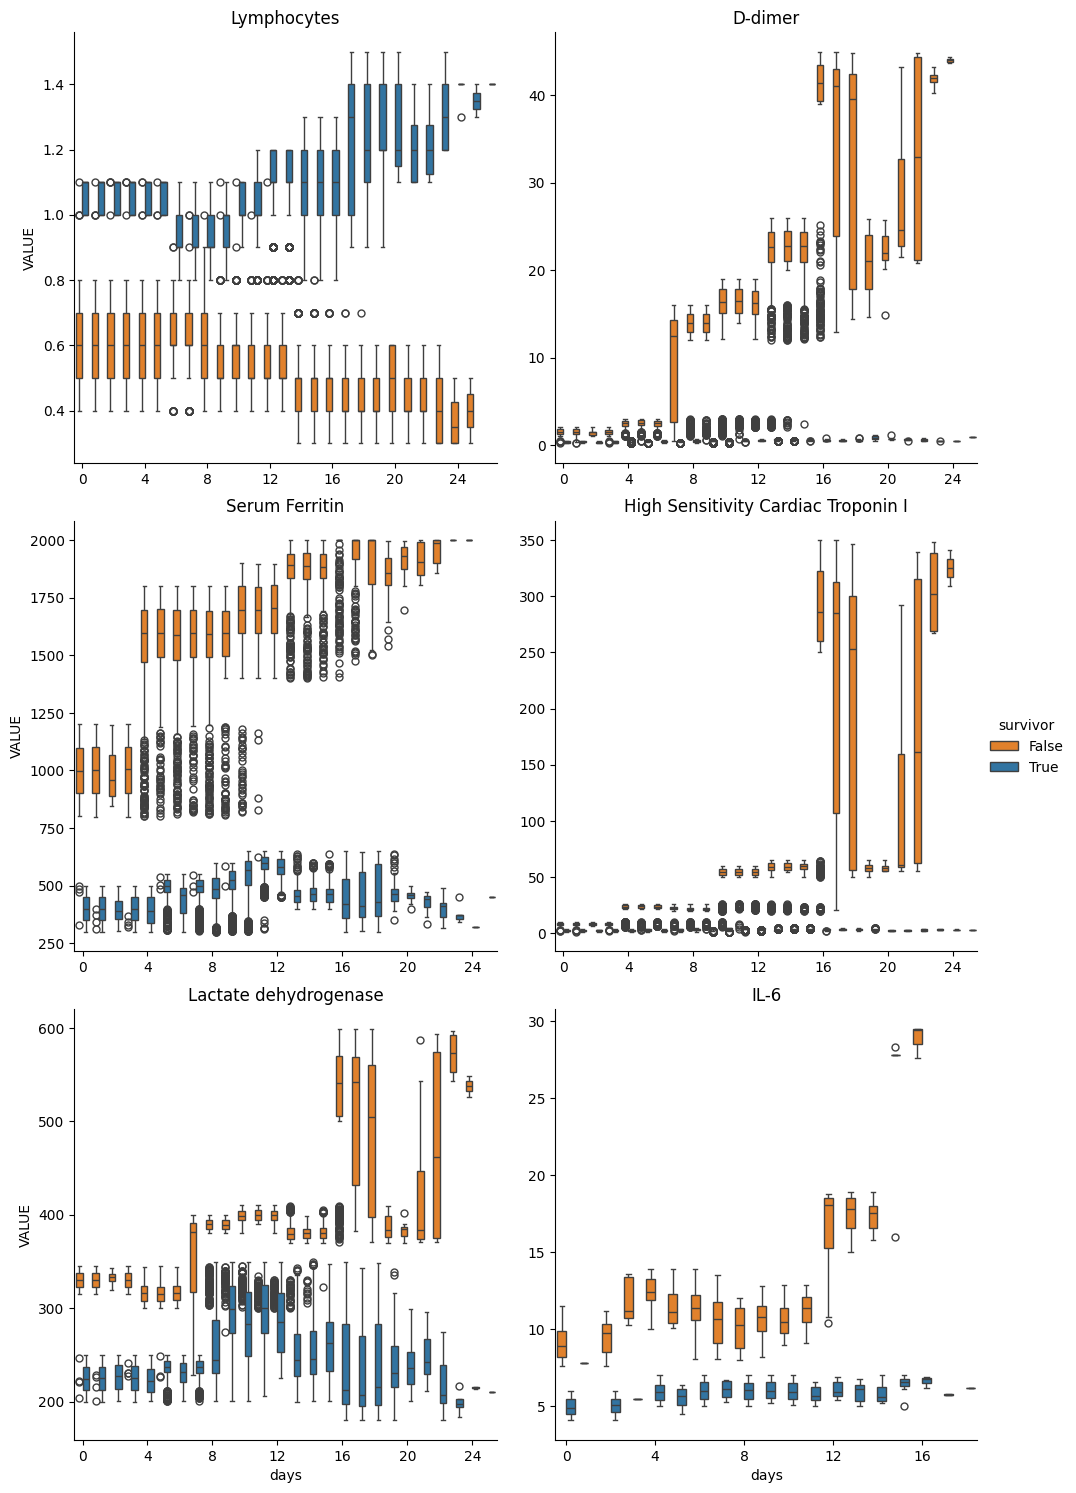

In [64]:
import matplotlib.ticker as ticker
loinc_to_display = {'CODE_y = 48065-7': 'D-dimer', 'CODE_y = 2276-4': 'Serum Ferritin',
                    'CODE_y = 89579-7': 'High Sensitivity Cardiac Troponin I',
                    'CODE_y = 26881-3': 'IL-6', 'CODE_y = 731-0': 'Lymphocytes',
                    'CODE_y = 14804-9': 'Lactate dehydrogenase'}
catplt = sns.catplot(x="days", y="VALUE", hue="survivor", kind="box", col='CODE_y',
            col_wrap=2, sharey=False, sharex=False, data=covid_patients_obs, palette=["C1", "C0"])

for axis in catplt.fig.axes:
    axis.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    axis.xaxis.set_major_locator(ticker.MultipleLocator(base=4))
    axis.set_title(loinc_to_display[axis.title.get_text()])

plt.show()

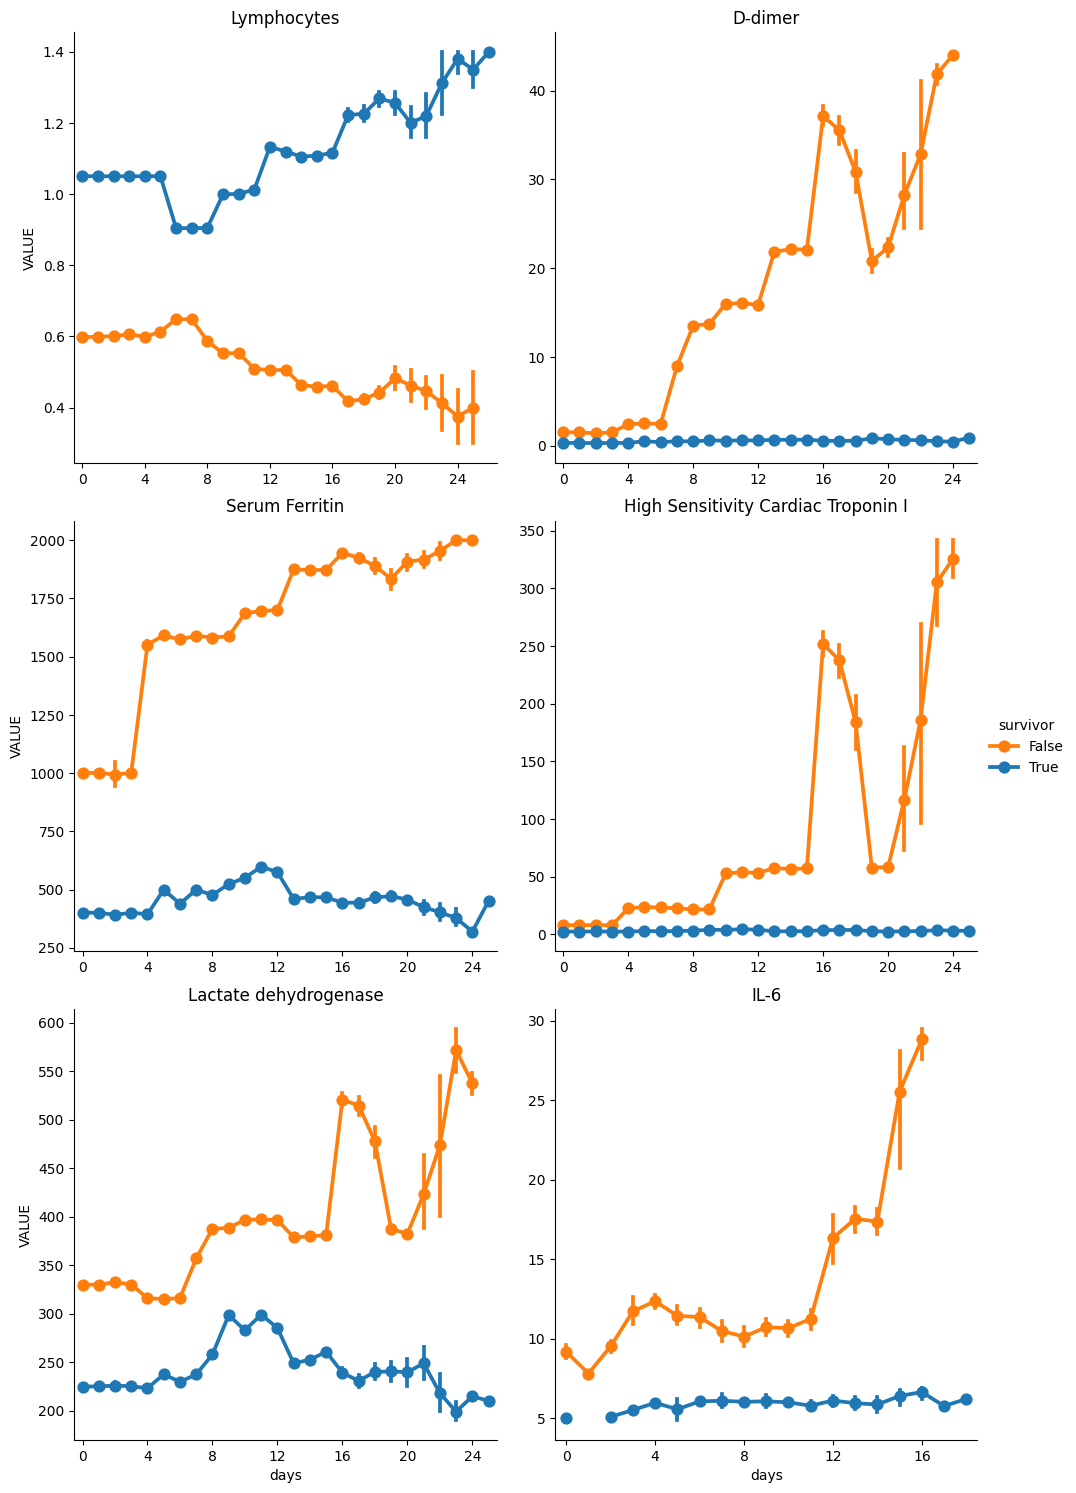

In [66]:
loinc_to_display = {'CODE_y = 48065-7': 'D-dimer', 'CODE_y = 2276-4': 'Serum Ferritin',
                    'CODE_y = 89579-7': 'High Sensitivity Cardiac Troponin I',
                    'CODE_y = 26881-3': 'IL-6', 'CODE_y = 731-0': 'Lymphocytes',
                    'CODE_y = 14804-9': 'Lactate dehydrogenase'}
catplt = sns.catplot(x="days", y="VALUE", hue="survivor", kind="point", col='CODE_y',
            col_wrap=2, sharey=False, sharex=False, data=covid_patients_obs, palette=["C1", "C0"])

for axis in catplt.fig.axes:
    axis.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    axis.xaxis.set_major_locator(ticker.MultipleLocator(base=4))
    axis.set_title(loinc_to_display[axis.title.get_text()])

plt.show()

Set up a new DataFrame with boolean columns representing various outcomes, like admit, recovery or death

In [68]:
# cp = covid_conditions.merge(patients, how='left', left_on='PATIENT', right_on='Id')
# isolation_ids = care_plans[(care_plans.CODE == 736376001) & (care_plans.REASONCODE == 840539006)].PATIENT
# cp['isolation'] = cp.Id.isin(isolation_ids)
# cp['admit'] = cp.Id.isin(inpatient_ids)
# cp['recovered'] = cp.Id.isin(survivor_ids)
# cp['death'] = cp.DEATHDATE.notna()
# icu_ids = encounters[encounters.CODE == 305351004].PATIENT
# cp['icu_admit'] = cp.Id.isin(icu_ids)
# vent_ids = procedures[procedures.CODE == 26763009].PATIENT
# cp['ventilated'] = cp.Id.isin(vent_ids)